# Animals Detection — Few-Shot Image Classification

In this jupyter norebook, we will compare 3 differentes méthods in order to have the best classification accuracy <br>
for the ~150 classes (with around 30 to 60 images per class). <br>
<br>
We will try :
 - A naïve method: K-nearest neighbour, using each images (224x224) as a 150K size vector. <br>
    No filter on the images, just raw pixels <br>
 - A Support Vector Machine method used on a 1280 size embedding created by the


## K-NN on the raw pixels

In [3]:
import os
import numpy as np
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_PATH = "dataset/dataset"
IMG_SIZE = (64, 64)  # 64x64 pour éviter 150k features 
valid_ext = {".jpg", ".jpeg", ".png"}

X, y = [], []

for label in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue
    for filename in os.listdir(class_path):
        if os.path.splitext(filename)[1].lower() not in valid_ext:
            continue
        img_path = os.path.join(class_path, filename)
        try:
            img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
            X.append(np.array(img).flatten().astype(np.float32) / 255.0)
            y.append(label)
        except:
            pass

X = np.array(X)
y = np.array(y)
print(f"Dataset: {X.shape[0]} images, {len(set(y))} classes, {X.shape[1]} features/image")

Dataset: 6270 images, 151 classes, 12288 features/image


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 5016 | Test: 1254


In [5]:
results = {}

for k in [1, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    results[f"KNN k={k}"] = {"accuracy": acc, "f1": f1, "preds": y_pred}
    print(f"k={k} → Accuracy: {acc:.2%} | F1-macro: {f1:.2%}")

k=1 → Accuracy: 5.58% | F1-macro: 5.08%
k=3 → Accuracy: 4.86% | F1-macro: 3.92%
k=5 → Accuracy: 5.18% | F1-macro: 4.06%


No a great accuracy, but however better than chance: 1/155 ~= 0.64%

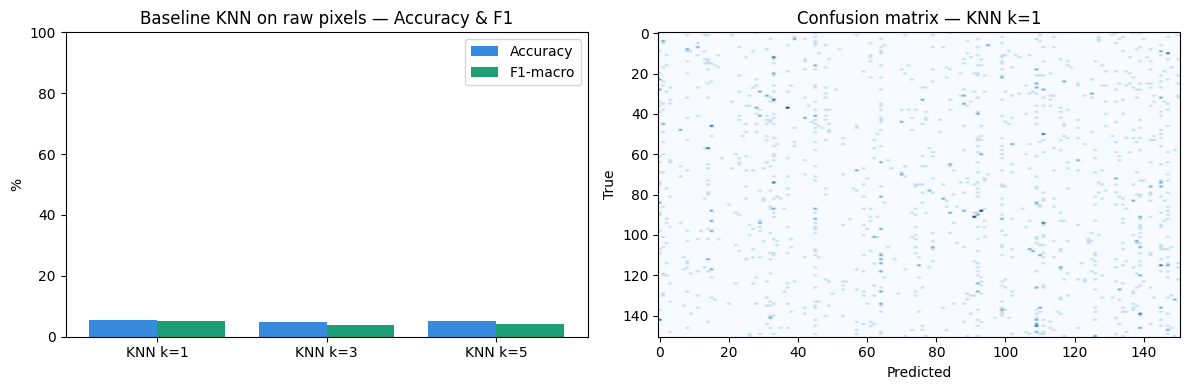

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart accuracy
labels_k = list(results.keys())
accs = [results[k]["accuracy"]*100 for k in labels_k]
f1s  = [results[k]["f1"]*100 for k in labels_k]

x = np.arange(len(labels_k))
axes[0].bar(x - 0.2, accs, 0.4, label='Accuracy', color='#378ADD')
axes[0].bar(x + 0.2, f1s,  0.4, label='F1-macro',  color='#1D9E75')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_k)
axes[0].set_ylabel("%")
axes[0].set_title("Baseline KNN on raw pixels — Accuracy & F1")
axes[0].legend()
axes[0].set_ylim(0, 100)

# Confusion matrix (meilleur k)
best_k = max(results, key=lambda k: results[k]["accuracy"])
cm = confusion_matrix(y_test, results[best_k]["preds"],
                      labels=sorted(set(y)))
axes[1].imshow(cm, cmap='Blues', aspect='auto')
axes[1].set_title(f"Confusion matrix — {best_k}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig("results_method1_knn_pixels.png", dpi=150)
plt.show()

## KNN + Principal Component analysis

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean', n_jobs=-1) # Cosine or euclidean for the metric
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)
print(f"KNN + PCA => Accuracy: {accuracy_score(y_test, y_pred):.2%}")

KNN + PCA => Accuracy: 7.42%


KNN + PCA → Accuracy: **7.81%** with cosine <br>
KNN + PCA → Accuracy: **7.42%** with euclidean metric


In [15]:
# Normalisation ImageNet au lieu de juste /255
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def normalize(flat_img):
    img = flat_img.reshape(64, 64, 3)
    img = (img - mean) / std
    return img.flatten()

X_norm = np.array([normalize(x) for x in X])
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)

pca = PCA(n_components=90, random_state=42)
X_train_pca = pca.fit_transform(X_train_n)
X_test_pca  = pca.transform(X_test_n)


knn = KNeighborsClassifier(n_neighbors=1, metric='cosine', n_jobs=-1)
knn.fit(X_train_pca, y_train_n)
y_pred = knn.predict(X_test_pca)
print(f"KNN normalized + PCA => Accuracy: {accuracy_score(y_test_n, y_pred):.2%}")

KNN normalized + PCA => Accuracy: 7.89%
